This version uses the CNN developed by the group, specifically, the keras model_1.

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Load Data

Assumes this folder structure

train/benign/

train/malignant/

test/benign/

test/malignant


### Step 1: Mount Google Drive

Run this cell to connect your Google Drive to this Colab session. You'll be prompted to authorize the connection.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

base_image_dir = '/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new'

# Define paths for test set
test_benign_dir = os.path.join(base_image_dir, 'test', 'benign')
test_malignant_dir = os.path.join(base_image_dir, 'test', 'malignant')

# Define paths for train set
train_benign_dir = os.path.join(base_image_dir, 'train', 'benign')
train_malignant_dir = os.path.join(base_image_dir, 'train', 'malignant')

# Function to count files in a directory
def count_images(directory_path):
    if os.path.exists(directory_path):
        # Count only files, not subdirectories
        return len([name for name in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, name))])
    else:
        return 0

# Get counts
count_test_benign = count_images(test_benign_dir)
count_test_malignant = count_images(test_malignant_dir)
count_train_benign = count_images(train_benign_dir)
count_train_malignant = count_images(train_malignant_dir)

# Print results
print(f"Number of images in {test_benign_dir}: {count_test_benign}")
print(f"Number of images in {test_malignant_dir}: {count_test_malignant}")
print(f"Number of images in {train_benign_dir}: {count_train_benign}")
print(f"Number of images in {train_malignant_dir}: {count_train_malignant}")

Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new/test/benign: 100
Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new/test/malignant: 117
Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new/train/benign: 400
Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new/train/malignant: 467


In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# IMPORTANT: Replace '/content/drive/MyDrive/your_image_data_folder/train'
# and '/content/drive/MyDrive/your_image_data_folder/test' with the actual paths
# to your 'train' and 'test' image folders in Google Drive.

# VERIFY THIS PATH AND THE SUBDIRECTORY STRUCTURE (e.g., /train/benign, /train/malignant)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    #'/content/drive/MyDrive/your_image_data_folder/train',
    '/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new/train',# Example path, replace with your actual path
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# VERIFY THIS PATH AND THE SUBDIRECTORY STRUCTURE (e.g., /test/benign, /test/malignant)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_new/test', # Example path, replace with your actual path
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 867 files belonging to 2 classes.
Found 217 files belonging to 2 classes.


Normalize Data

In [7]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Build CNN Model

To copy group's CNN, changed dropout rate to .3 (from .5)


In [8]:
# My intial model
# model = keras.Sequential([
#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
#     layers.MaxPooling2D(),

#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D(),

#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.MaxPooling2D(),

#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(1, activation='sigmoid')
# ])

#Chances' model_1

def build_arch1_model(img_size=(224, 224), pooling='avg', dropout_rate=0.3):
  pooling_layer = layers.GlobalAveragePooling2D() if pooling == 'avg' else layers.GlobalMaxPooling2D()

  model = keras.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    pooling_layer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
  ])

  return model

# Choose the architecture to train
POOLING = 'avg'         # 'avg' or 'max'

# tf.keras.backend.clear_session()

model = build_arch1_model(img_size=IMG_SIZE, pooling=POOLING)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    # metrics=['accuracy']
    metrics=[
    "accuracy",
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

Epochs changed from 10 to 35

In [10]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=35
)

Epoch 1/35
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5467 - auc: 0.5159 - loss: 0.6921 - precision: 0.5658 - recall: 0.6809 - val_accuracy: 0.5760 - val_auc: 0.6593 - val_loss: 0.6849 - val_precision: 0.5628 - val_recall: 0.9573
Epoch 2/35
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.5663 - auc: 0.5818 - loss: 0.6843 - precision: 0.5554 - recall: 0.9764 - val_accuracy: 0.5991 - val_auc: 0.6706 - val_loss: 0.6728 - val_precision: 0.5798 - val_recall: 0.9316
Epoch 3/35
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.5986 - auc: 0.6292 - loss: 0.6705 - precision: 0.6313 - recall: 0.6124 - val_accuracy: 0.6129 - val_auc: 0.6785 - val_loss: 0.6590 - val_precision: 0.5902 - val_recall: 0.9231
Epoch 4/35
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.5894 - auc: 0.6332 - loss: 0.6722 - precision: 0.6331 - recall: 0.5653 - val_accuracy: 0.5991 - val_auc: 0.7264 - val_loss: 0.6668 - val_precision: 0.5750 - val_recall: 0.9829
Epoch 5/35
28/28 ━━━━━━━━━━━━━━━━━

Evaluate Model


In [12]:
loss, acc, auc, precision, recall = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.6959 - auc: 0.7350 - loss: 0.5866 - precision: 0.7040 - recall: 0.7521
Test Accuracy: 0.6959


In [14]:
# evaluate
results = model.evaluate(test_ds, return_dict=True)
print(results)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.6959 - auc: 0.7350 - loss: 0.5866 - precision: 0.7040 - recall: 0.7521
{'accuracy': 0.695852518081665, 'auc': 0.7350427508354187, 'loss': 0.5866116285324097, 'precision': 0.7039999961853027, 'recall': 0.752136766910553}


In [15]:
from sklearn.metrics import classification_report

# Get true labels from test_ds
# Since test_ds has shuffle=False, labels will be in order
true_labels = []
for _, labels in test_ds:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

# Get predictions from the model
predictions = model.predict(test_ds)

# Convert probabilities to binary predictions (0 or 1)
predicted_labels = (predictions > 0.5).astype(int)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.63      0.66       100
         1.0       0.70      0.75      0.73       117

    accuracy                           0.70       217
   macro avg       0.69      0.69      0.69       217
weighted avg       0.70      0.70      0.69       217



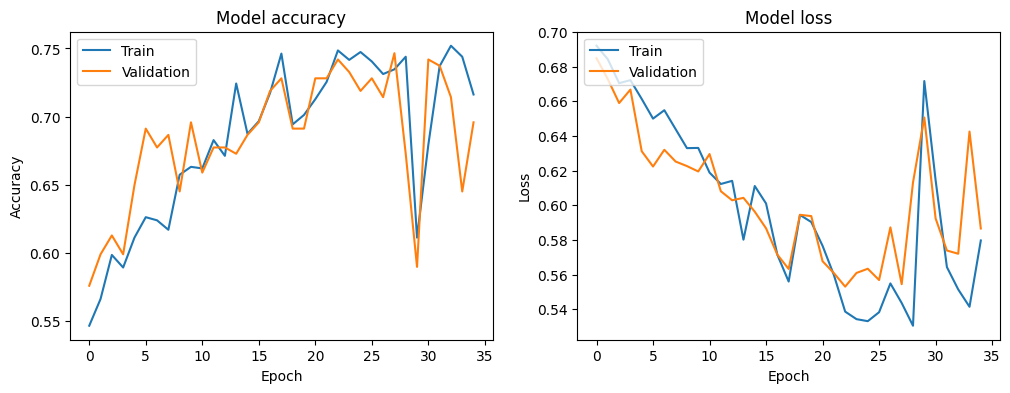

In [17]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# plot
plot_training_history(history)

Occlusion Sensitivity Map

In [18]:
def occlusion_sensitivity(model, image, label, patch_size=20, stride=10):
    image = image.numpy()
    h, w, _ = image.shape
    heatmap = np.zeros((h, w))

    # Get baseline prediction
    baseline = model.predict(image[np.newaxis, ...])[0][0]

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            occluded = image.copy()
            occluded[y:y+patch_size, x:x+patch_size, :] = 0.5  # gray patch

            pred = model.predict(occluded[np.newaxis, ...])[0][0]

            impact = baseline - pred
            heatmap[y:y+patch_size, x:x+patch_size] += impact

    return heatmap

Visualize occlusion map

Sample Image Label: [0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

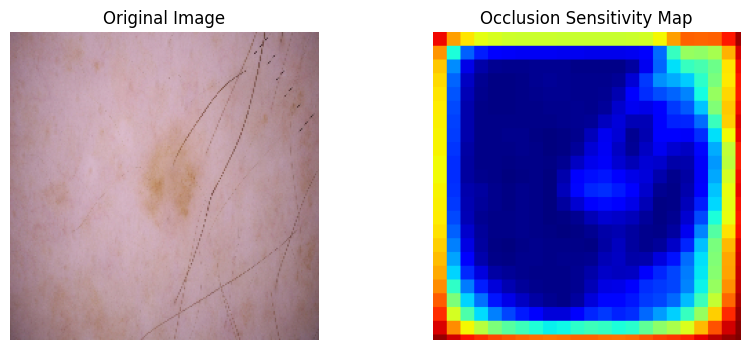

In [19]:
for images, labels in test_ds.take(1):
    sample_img = images[0]
    sample_label = labels[0]

print(f"Sample Image Label: {sample_label}")

heatmap = occlusion_sensitivity(model, sample_img, sample_label)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Occlusion Sensitivity Map")
plt.axis('off')

plt.show()

### Occlusion Map for a Malignant Image

Found Malignant Image with Label: [1.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━

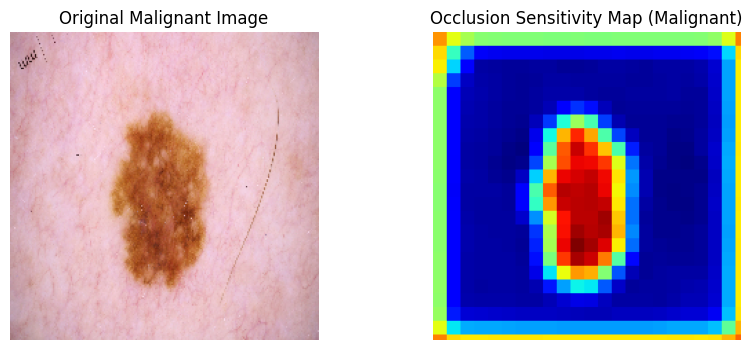

In [20]:
malignant_img = None
malignant_label = None

# Iterate through the test dataset to find a malignant image
for images, labels in test_ds:
    for i in range(len(labels)):
        if labels[i].numpy() == 1.0: # Check for malignant label (assuming 1.0 for malignant)
            malignant_img = images[i]
            malignant_label = labels[i]
            break
    if malignant_img is not None:
        break

if malignant_img is not None:
    print(f"Found Malignant Image with Label: {malignant_label}")
    heatmap_malignant = occlusion_sensitivity(model, malignant_img, malignant_label)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(malignant_img)
    plt.title("Original Malignant Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(heatmap_malignant, cmap='jet')
    plt.title("Occlusion Sensitivity Map (Malignant)")
    plt.axis('off')

    plt.show()
else:
    print("Could not find a malignant image in the test dataset.")


Interpretation

* Bright/red regions = important for prediction
* Dark/blue regions = less important

Why this matters:

* Helps identify **regions of interest (ROI)**
* Can guide **better cropping or preprocessing**
* Improves **model trust and explainability**



Optional Improvements

* Use **transfer learning** (e.g., MobileNet, ResNet)
* Tune patch size for occlusion
* Apply smoothing to heatmap